In [66]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [84]:
logits = torch.from_numpy(np.random.normal(0, 2, (200, 50)))

In [85]:
logits.shape

torch.Size([200, 50])

In [86]:
logits[0]

tensor([ 0.0813,  1.2325,  2.1925,  2.3527, -1.4171,  1.2157, -1.3945, -3.7560,
         0.8377,  3.5990, -0.3591, -1.8695,  3.7233,  1.1701, -0.4150,  0.2537,
         0.2994,  0.7173,  0.3020,  1.9211,  0.7705, -1.5309,  0.3041, -3.0049,
        -2.0252,  2.9498,  1.1824, -3.1751,  0.8891,  0.4481,  0.2320,  3.4794,
        -0.6247, -2.1735, -3.9474, -1.0835, -0.3866,  1.6265,  1.1825, -1.1794,
        -2.3113, -1.4161, -0.2122,  0.7510,  0.7919, -2.4735,  2.7518, -0.1934,
         1.1004, -0.8324], dtype=torch.float64)

In [87]:
weights = torch.softmax(logits, dim=-1)

In [88]:
weights.shape

torch.Size([200, 50])

In [89]:
torch.sum(weights[0])

tensor(1., dtype=torch.float64)

In [90]:
torch.sum(weights, dim=-1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 

In [91]:
xgrid = torch.outer(torch.ones(weights.shape[-1]), torch.arange(weights.shape[-1]))

In [92]:
xgrid.shape

torch.Size([50, 50])

In [93]:
xgrid

tensor([[ 0.,  1.,  2.,  ..., 47., 48., 49.],
        [ 0.,  1.,  2.,  ..., 47., 48., 49.],
        [ 0.,  1.,  2.,  ..., 47., 48., 49.],
        ...,
        [ 0.,  1.,  2.,  ..., 47., 48., 49.],
        [ 0.,  1.,  2.,  ..., 47., 48., 49.],
        [ 0.,  1.,  2.,  ..., 47., 48., 49.]])

In [94]:
means = xgrid.T

In [95]:
means

tensor([[ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 1.,  1.,  1.,  ...,  1.,  1.,  1.],
        [ 2.,  2.,  2.,  ...,  2.,  2.,  2.],
        ...,
        [47., 47., 47.,  ..., 47., 47., 47.],
        [48., 48., 48.,  ..., 48., 48., 48.],
        [49., 49., 49.,  ..., 49., 49., 49.]])

In [147]:
bandwidth = 1

In [148]:
gaussians = 1/(math.sqrt(2*math.pi)*bandwidth)*torch.exp(-0.5*((xgrid - means)/bandwidth)**2)

In [149]:
gaussians

tensor([[0.3989, 0.2420, 0.0540,  ..., 0.0000, 0.0000, 0.0000],
        [0.2420, 0.3989, 0.2420,  ..., 0.0000, 0.0000, 0.0000],
        [0.0540, 0.2420, 0.3989,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.3989, 0.2420, 0.0540],
        [0.0000, 0.0000, 0.0000,  ..., 0.2420, 0.3989, 0.2420],
        [0.0000, 0.0000, 0.0000,  ..., 0.0540, 0.2420, 0.3989]])

In [150]:
gaussians.sum(dim=-1)

tensor([0.6995, 0.9414, 0.9954, 0.9999, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 0.9999, 0.9954, 0.9414, 0.6995])

In [151]:
weights.dtype

torch.float64

In [152]:
gaussians.dtype

torch.float32

In [153]:
probs = weights.to(torch.float32) @ gaussians

In [154]:
probs.shape

torch.Size([200, 50])

In [155]:
normalizations = torch.outer(torch.sum(probs, dim=-1), torch.ones(probs.shape[-1]))

In [156]:
normalizations.shape

torch.Size([200, 50])

In [157]:
probs /= normalizations

In [158]:
torch.sum(probs, dim=-1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 

In [159]:
bin_edges = np.linspace(-3,9,51)

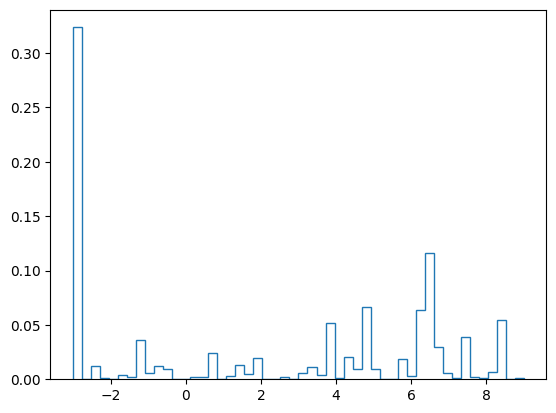

In [ ]:
plt.stairs(weights[14], bin_edges)

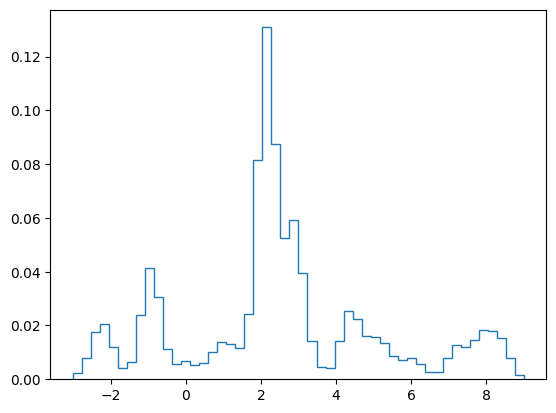

In [165]:
plt.stairs(probs[5], bin_edges)

In [166]:
log_probs = torch.log(probs)

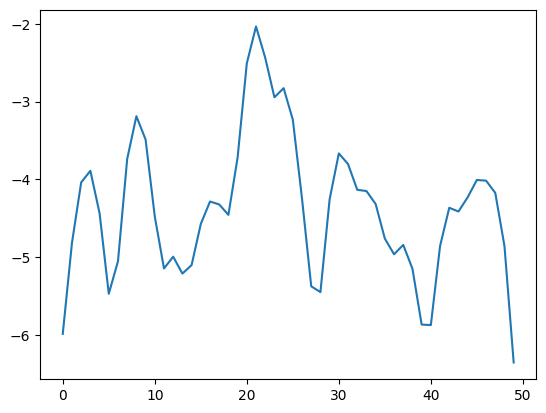

In [169]:
plt.plot(log_probs[5])